In [1]:
# =====================================
# Fake News Headline Detector
# Import Required Libraries
# =====================================

import pandas as pd
import numpy as np
import re
import string
import warnings

warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [2]:
# =====================================
# Load Dataset
# =====================================

true_df = pd.read_csv("/content/True.csv")
fake_df = pd.read_csv("/content/Fake.csv")

print("True News Shape :", true_df.shape)
print("Fake News Shape :", fake_df.shape)

True News Shape : (21417, 4)
Fake News Shape : (23481, 4)


In [3]:
# =====================================
# Add Labels
# REAL = 0
# FAKE = 1
# =====================================

true_df["label"] = 0
fake_df["label"] = 1

In [4]:
# =====================================
# Merge Dataset
# =====================================

df = pd.concat([true_df, fake_df], axis=0)

# Shuffle dataset
df = df.sample(frac=1, random_state=42)

# Reset index
df.reset_index(drop=True, inplace=True)

print(df.shape)

df.head()

(44898, 5)


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",1


In [5]:
# =====================================
# Keep Only Headline and Label
# =====================================

df = df[["title", "label"]]

# Rename title column
df.rename(columns={"title": "headline"}, inplace=True)

df.head()

,headline,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,1
1,Failed GOP Candidates Remembered In Hilarious...,1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,1
3,California AG pledges to defend birth control ...,0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,1


In [6]:
# =====================================
# Missing Value Check
# =====================================

print(df.isnull().sum())

df.dropna(inplace=True)

print("Final Dataset Shape :", df.shape)

headline    0
label       0
dtype: int64
Final Dataset Shape : (44898, 2)


label
1    23481
0    21417
Name: count, dtype: int64


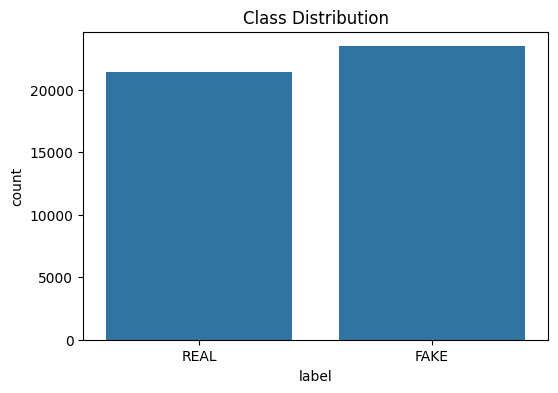

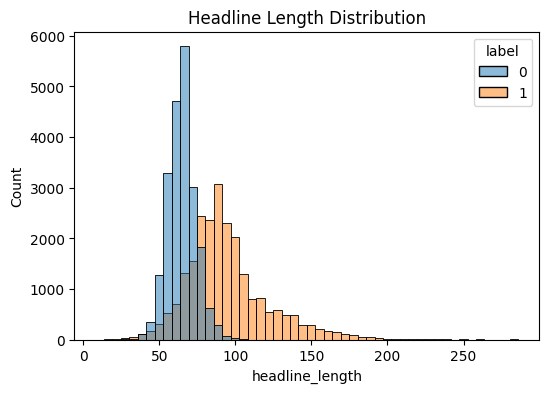

In [7]:
# =====================================
# Step 7: Basic EDA
# =====================================

print(df["label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Class Distribution")
plt.xticks([0, 1], ["REAL", "FAKE"])
plt.show()

df["headline_length"] = df["headline"].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="headline_length", hue="label", bins=50)
plt.title("Headline Length Distribution")
plt.show()

In [8]:
# =====================================
# Step 8: Text Cleaning
# =====================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_headline"] = df["headline"].apply(clean_text)

df[["headline", "clean_headline", "label"]].head()

,headline,clean_headline,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,breaking gop chairman grassley has had enough ...,1
1,Failed GOP Candidates Remembered In Hilarious...,failed gop candidates remembered in hilarious ...,1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,mike pence’s new dc neighbors are hilariously ...,1
3,California AG pledges to defend birth control ...,california ag pledges to defend birth control ...,0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,az ranchers living on usmexico border destroy ...,1


In [9]:
# =====================================
# Step 9: Train Test Split
# =====================================

X = df["clean_headline"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (35918,)
Testing Data: (8980,)


In [10]:
# =====================================
# Step 10: TF-IDF Feature Extraction
# =====================================

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)

TF-IDF Train Shape: (35918, 10000)
TF-IDF Test Shape: (8980, 10000)


In [11]:
# =====================================
# Step 11: Logistic Regression Model
# =====================================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
lr_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


In [12]:
# =====================================
# Step 12: Evaluation
# =====================================

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("AUC-ROC  :", lr_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred, target_names=["REAL", "FAKE"]))

Logistic Regression Performance
--------------------------------
Accuracy : 0.9388641425389755
Precision: 0.9452437191324887
Recall   : 0.9373935264054515
F1 Score : 0.9413022559606543
AUC-ROC  : 0.9842288846259685

Classification Report:

              precision    recall  f1-score   support

        REAL       0.93      0.94      0.94      4284
        FAKE       0.95      0.94      0.94      4696

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



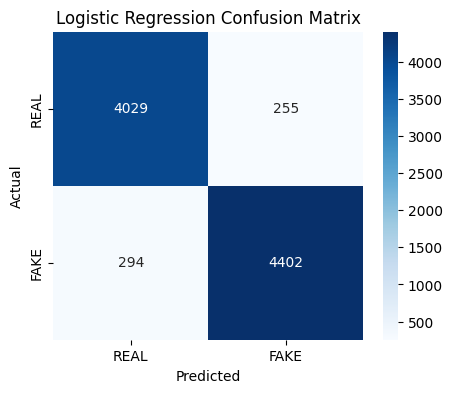

In [13]:
# =====================================
# Step 13: Confusion Matrix
# =====================================

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [14]:
# =====================================
# Step 14: Single Headline Prediction
# =====================================

def predict_headline(headline):
    cleaned = clean_text(headline)
    vectorized = tfidf.transform([cleaned])

    prediction = lr_model.predict(vectorized)[0]
    probability = lr_model.predict_proba(vectorized)[0]

    label = "FAKE" if prediction == 1 else "REAL"
    confidence = max(probability) * 100

    print("Headline:", headline)
    print("Prediction:", label)
    print("Confidence:", round(confidence, 2), "%")

predict_headline("Breaking news: Government announces new education policy")

Headline: Breaking news: Government announces new education policy
Prediction: FAKE
Confidence: 93.84 %


In [15]:
# =====================================
# Step 15: Naive Bayes Model
# =====================================

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
nb_prob = nb_model.predict_proba(X_test_tfidf)[:, 1]

print("Naive Bayes Training Complete")

Naive Bayes Training Complete


In [16]:
# =====================================
# Step 16: Naive Bayes Evaluation
# =====================================

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)
nb_auc = roc_auc_score(y_test, nb_prob)

print("Naive Bayes Performance")
print("--------------------------------")

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)
print("AUC-ROC  :", nb_auc)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    nb_pred,
    target_names=["REAL", "FAKE"]
))

Naive Bayes Performance
--------------------------------
Accuracy : 0.9328507795100223
Precision: 0.9289457136868581
Recall   : 0.9437819420783645
F1 Score : 0.9363050596809972
AUC-ROC  : 0.9835236834654361

Classification Report:

              precision    recall  f1-score   support

        REAL       0.94      0.92      0.93      4284
        FAKE       0.93      0.94      0.94      4696

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



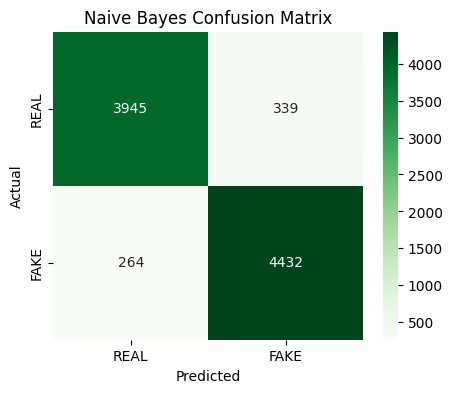

In [17]:
# =====================================
# Step 17: Naive Bayes Confusion Matrix
# =====================================

cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["REAL", "FAKE"],
    yticklabels=["REAL", "FAKE"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [18]:
# =====================================
# Step 18: Model Comparison
# =====================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Naive Bayes"
    ],

    "Accuracy": [
        lr_accuracy,
        nb_accuracy
    ],

    "Precision": [
        lr_precision,
        nb_precision
    ],

    "Recall": [
        lr_recall,
        nb_recall
    ],

    "F1 Score": [
        lr_f1,
        nb_f1
    ],

    "AUC-ROC": [
        lr_auc,
        nb_auc
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.938864,0.945244,0.937394,0.941302,0.984229
1,Naive Bayes,0.932851,0.928946,0.943782,0.936305,0.983524


In [19]:
# =====================================
# Step 19: Top FAKE Predictive Words
# =====================================

feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[0]

fake_words_df = pd.DataFrame({
    "word": feature_names,
    "score": coefficients
})

# Top FAKE predictive words
top_fake_words = fake_words_df.sort_values(
    by="score",
    ascending=False
).head(20)

top_fake_words

,word,score
9502,video,10.580967
3782,hillary,9.485358
9673,watch,8.790023
969,breaking,8.494006
4468,just,7.728932
3438,gop,7.474046
254,america,5.317709
5765,obama,4.942307
9865,won,4.702613
6437,president trump,4.665876


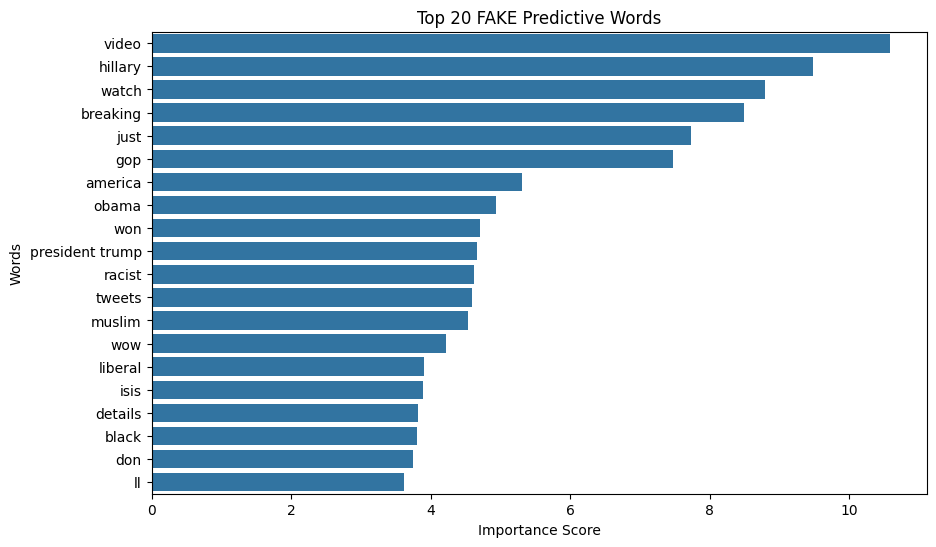

In [20]:
# =====================================
# Step 20: Plot Top Fake Words
# =====================================

plt.figure(figsize=(10,6))

sns.barplot(
    x="score",
    y="word",
    data=top_fake_words
)

plt.title("Top 20 FAKE Predictive Words")
plt.xlabel("Importance Score")
plt.ylabel("Words")

plt.show()

In [21]:
# =====================================
# Step 21: Create Suspicious Words List
# =====================================

suspicious_words = top_fake_words["word"].tolist()

print(suspicious_words)

['video', 'hillary', 'watch', 'breaking', 'just', 'gop', 'america', 'obama', 'won', 'president trump', 'racist', 'tweets', 'muslim', 'wow', 'liberal', 'isis', 'details', 'black', 'don', 'll']


In [23]:
# =====================================
# Step 22: Highlight Suspicious Words
# =====================================

def highlight_suspicious_words(headline):
    words = headline.split()
    highlighted_words = []

    for word in words:
        clean_word = clean_text(word)

        if clean_word in suspicious_words:
            highlighted_words.append(f"[{word}]")
        else:
            highlighted_words.append(word)

    return " ".join(highlighted_words)

In [24]:
# =====================================
# Step 23: Test Suspicious Word Highlighting
# =====================================

test_headline = "Breaking video shows Hillary watch America"

print("Original Headline:")
print(test_headline)

print("\nHighlighted Headline:")
print(highlight_suspicious_words(test_headline))

Original Headline:
Breaking video shows Hillary watch America

Highlighted Headline:
[Breaking] [video] shows [Hillary] [watch] [America]


In [26]:
# =====================================
# Step 24: Prediction with Highlight
# =====================================

def predict_with_highlight(headline):
    cleaned = clean_text(headline)
    vectorized = tfidf.transform([cleaned])

    prediction = lr_model.predict(vectorized)[0]
    probability = lr_model.predict_proba(vectorized)[0]

    label = "FAKE" if prediction == 1 else "REAL"
    confidence = max(probability) * 100

    highlighted = highlight_suspicious_words(headline)

    print("Headline:", headline)
    print("Prediction:", label)
    print("Confidence:", round(confidence, 2), "%")
    print("Highlighted:", highlighted)

In [27]:
predict_with_highlight("Breaking video shows Hillary watch America")

Headline: Breaking video shows Hillary watch America
Prediction: FAKE
Confidence: 100.0 %
Highlighted: [Breaking] [video] shows [Hillary] [watch] [America]


In [28]:
# =====================================
# Step 26: Save Model and Vectorizer
# =====================================

import joblib

joblib.dump(lr_model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(suspicious_words, "suspicious_words.pkl")

print("Model, vectorizer, and suspicious words saved successfully!")

Model, vectorizer, and suspicious words saved successfully!


In [29]:
# =====================================
# Step 27: Download Files
# =====================================

from google.colab import files

files.download("fake_news_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("suspicious_words.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>